In [233]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from IPython.display import display, HTML

# Téléchargement des ressources NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("Terminé.")

Terminé.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\L580\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\L580\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\L580\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [42]:
def load_data(file_path):
    labels, texts = [], []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(None, 1)
            if len(parts) > 1:
                labels.append(parts[0])
                texts.append(parts[1])
    return pd.DataFrame({'label': labels, 'text': texts})

# Chemins à adapter selon votre ordinateur
train_df = load_data(r'C:\Users\L580\Downloads\archive\train.dat')
test_df = load_data(r'C:\Users\L580\Downloads\archive\test.dat')

print(f"Train: {train_df.shape[0]} records | Test: {test_df.shape[0]} records")
train_df.head()

Train: 14438 records | Test: 14442 records


,label,text
0,4,Catheterization laboratory events and hospital...
1,5,Renal abscess in children. Three cases of rena...
2,2,Hyperplastic polyps seen at sigmoidoscopy are ...
3,5,Subclavian artery to innominate vein fistula a...
4,4,Effect of local inhibition of gamma-aminobutyr...


In [643]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # 1. Passage en minuscules
    text = text.lower()
    # 2. Suppression ponctuation et chiffres
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Tokenization + Suppression Stopwords + Lemmatisation
    tokens = text.split()
    cleaned = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return " ".join(cleaned)

# On applique le nettoyage sur le train et le test
print("Nettoyage du texte en cours...")
train_df['clean_text'] = train_df['text'].apply(preprocess_text)
test_df['clean_text'] = test_df['text'].apply(preprocess_text)
print("Nettoyage terminé.")

Nettoyage du texte en cours...
Nettoyage terminé.


In [645]:
# Affichage d'un exemple avant/après
data_example = {
    "Étape": [" Texte Original", " Texte Nettoyé"],
    "Contenu": [
        train_df['text'].iloc[0][:300] + "...",  
        train_df['clean_text'].iloc[0][:300] + "..."
    ]
}
df_comparaison = pd.DataFrame(data_example)

styled_df = df_comparaison.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'normal',
    'font-family': 'Segoe UI'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#831C91'), ('color', 'white'), ('font-size', '14px')]}
])
print("--- COMPARAISON DU PRÉTRAITEMENT ---")
display(styled_df)

--- COMPARAISON DU PRÉTRAITEMENT ---


,Étape,Contenu
0,Texte Original,"Catheterization laboratory events and hospital outcome with direct angioplasty for acute myocardial infarction To assess the safety of direct infarct angioplasty without antecedent thrombolytic therapy, catheterization laboratory and hospital events were assessed in consecutively treated patients wi..."
1,Texte Nettoyé,catheterization laboratory event hospital outcome direct angioplasty acute myocardial infarction assess safety direct infarct angioplasty without antecedent thrombolytic therapy catheterization laboratory hospital event assessed consecutively treated patient infarction involving left anterior descen...


In [169]:
class_docs = train_df.groupby('label')['clean_text'].apply(lambda x: ' '.join(x))
# On ignore les mots présents dans 70% des classes (ex: patient, group)
vectorizer_check = TfidfVectorizer(max_df=0.7, stop_words='english')
tfidf_check = vectorizer_check.fit_transform(class_docs)
feature_names = vectorizer_check.get_feature_names_out()

print("--- SIGNATURES PAR LABEL (MOTS PERTINENTS UNIQUEMENT) ---")
for i, label in enumerate(class_docs.index):
    scores = tfidf_check.getrow(i).toarray()[0]
    top_indices = scores.argsort()[-8:][::-1]
    print(f"Label {label} : {', '.join([feature_names[idx] for idx in top_indices])}")

--- SIGNATURES PAR LABEL (MOTS PERTINENTS UNIQUEMENT) ---
Label 1 : hpv, mastectomy, mammography, papillomavirus, hcc, leukemic, glioma, oncogene
Label 2 : hbv, helicobacter, hbsag, esophagitis, achalasia, dissolution, rehydration, volvulus
Label 3 : spasticity, antiepileptic, cbz, neuroleptic, tourette, dystonia, levodopa, aphasia
Label 4 : angioplasty, thallium, ptca, myocardium, cad, doxazosin, transluminal, shr
Label 5 : angioplasty, ptca, transluminal, intimal, antiarrhythmic, bupivacaine, breathing, hbv


In [58]:
mapping = {
    '1': 'Neoplasms',
    '2': 'Digestive System',
    '3': 'Nervous System',
    '4': 'Cardiovascular',
    '5': 'General Pathological'
}
train_df['class_name'] = train_df['label'].map(mapping)

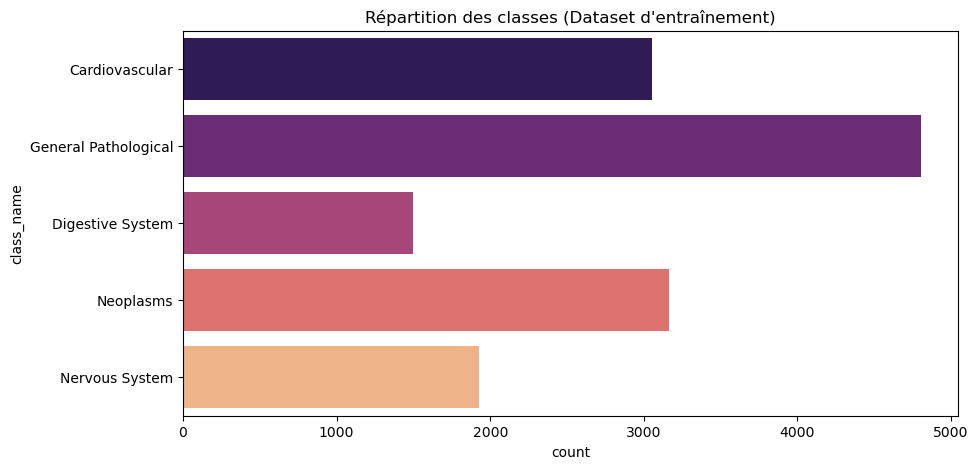

In [63]:
# Graphique de répartition
plt.figure(figsize=(10,5))
sns.countplot(y='class_name', data=train_df, hue='class_name', palette='magma', legend=False)
plt.title('Répartition des classes (Dataset d\'entraînement)')
plt.show()

In [176]:
# 80% (Entraînement) et 20% (Validation interne)
X_train, X_val, y_train, y_val = train_test_split(
    train_df['clean_text'], 
    train_df['label'], 
    test_size=0.2, 
    random_state=42,
    stratify=train_df['label']
)
print(f"Entraînement : {len(X_train)} abstracts")
print(f"Validation   : {len(X_test)} abstracts")

Entraînement : 11550 abstracts
Validation   : 2888 abstracts


In [571]:
# Paramètres : max_features=10000 (standard), C=1.0, Pas de SelectKBest
baseline_data = []
ngram_baseline_options = [(1, 1), (2, 2), (1, 2)]

print("Calcul de la Baseline en cours...")
for ngram in ngram_baseline_options:
    if ngram == (1, 1): name = "Unigrammes"
    elif ngram == (2, 2): name = "Bigrammes"
    else: name = "Mix (1,2)"
    
    vec = TfidfVectorizer(ngram_range=ngram, max_features=10000)
    X_tr = vec.fit_transform(X_train)
    X_vl = vec.transform(X_val)
    
    model = LogisticRegression(max_iter=2000, C=1.0)
    model.fit(X_tr, y_train)
    acc = accuracy_score(y_val, model.predict(X_vl))
    baseline_data.append({'N-gramme': name, 'Accuracy Baseline': acc})

df_baseline = pd.DataFrame(baseline_data)
display(df_baseline)

Calcul de la Baseline en cours...


,N-gramme,Accuracy Baseline
0,Unigrammes,0.576870
1,Bigrammes,0.514889
2,"Mix (1,2)",0.577562


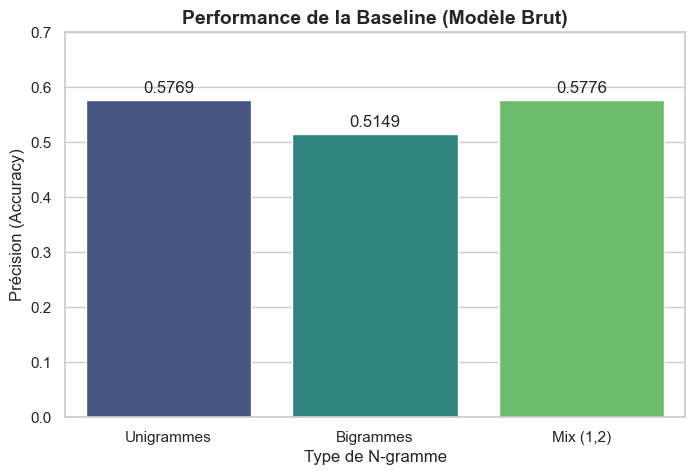

In [573]:
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# graphique
ax = sns.barplot(x='N-gramme', y='Accuracy Baseline', data=df_baseline, palette='viridis',hue='N-gramme', legend=False)
plt.title('Performance de la Baseline (Modèle Brut)', fontsize=14, fontweight='bold')
plt.ylabel('Précision (Accuracy)')
plt.xlabel('Type de N-gramme')
plt.ylim(0, 0.7) 

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.show()

In [575]:
#  GRID SEARCH (Impact de Pool, K et C) ---
max_features_options = [10000, 20000]
k_options = [1500, 2000, 5000]
c_options = [0.1, 1, 10, 100]
ngram_options = [(1, 1), (2, 2), (1, 2)]

results_comp = []

for max_f in max_features_options:
    print(f"\n>>> Analyse avec Réservoir (Max Features) = {max_f}")
    for ngram in ngram_options:
        if ngram == (1, 1): ngram_name = "Unigrammes"
        elif ngram == (2, 2): ngram_name = "Bigrammes"
        else: ngram_name = "Mix (1,2)"
        
        # Vectorisation avec le pool actuel
        vec = TfidfVectorizer(ngram_range=ngram, max_features=max_f)
        X_tr_raw = vec.fit_transform(X_train)
        X_vl_raw = vec.transform(X_val)

        for k in k_options:
            selector = SelectKBest(chi2, k=k)
            X_tr_final = selector.fit_transform(X_tr_raw, y_train)
            X_vl_final = selector.transform(X_vl_raw)

            for c in c_options:
                model = LogisticRegression(max_iter=2000, C=c)
                model.fit(X_tr_final, y_train)
                acc = accuracy_score(y_val, model.predict(X_vl_final))

                results_comp.append({
                    'Max_Features_Pool': max_f,
                    'N-gramme': ngram_name,
                    'K_Features': k,
                    'C_Param': c, 
                    'Accuracy': acc
                })

df_comp = pd.DataFrame(results_comp)
print("\nOptimisation terminée !")


>>> Analyse avec Réservoir (Max Features) = 10000

>>> Analyse avec Réservoir (Max Features) = 20000

Optimisation terminée !


In [579]:
pools = [10000, 20000]
ngrams = ["Unigrammes", "Bigrammes", "Mix (1,2)"] 

for pool in pools:
    print("\n" + "#"*70)
    print(f"      SCÉNARIO : MAX_FEATURES_POOL = {pool}")
    print("#"*70)
    
    # Filtrage par pool
    df_pool = df_comp[df_comp['Max_Features_Pool'] == pool]
    
    for name in ngrams:
        # Filtrage par type de n-gramme
        df_sub = df_pool[df_pool['N-gramme'] == name]
        
        if not df_sub.empty:
            # Création du pivot
            pivot = df_sub.pivot(index='K_Features', columns='C_Param', values='Accuracy')
            
            print(f"\n--- Matrice d'optimisation : {name} (Pool {pool}) ---")
            display(pivot)
        else:
            print(f"\n[Info] Pas de données pour {name} dans le pool {pool}")


######################################################################
      SCÉNARIO : MAX_FEATURES_POOL = 10000
######################################################################

--- Matrice d'optimisation : Unigrammes (Pool 10000) ---


C_Param,0.1,1.0,10.0,100.0
K_Features,,,,
1500,0.544321,0.601801,0.584834,0.555055
2000,0.545014,0.603532,0.570291,0.522853
5000,0.547091,0.589335,0.528047,0.447368



--- Matrice d'optimisation : Bigrammes (Pool 10000) ---


C_Param,0.1,1.0,10.0,100.0
K_Features,,,,
1500,0.466066,0.542590,0.541205,0.521468
2000,0.465720,0.547438,0.535319,0.503116
5000,0.473684,0.537742,0.479917,0.408587



--- Matrice d'optimisation : Mix (1,2) (Pool 10000) ---


...

C_Param,0.1,1.0,10.0,100.0
K_Features,,,,
1500,0.537050,0.599377,0.586219,0.556440
2000,0.536357,0.599030,0.569945,0.527701
5000,0.542936,0.591066,0.540859,0.477839



--- Matrice d'optimisation : Bigrammes (Pool 20000) ---


C_Param,0.1,1.0,10.0,100.0
K_Features,,,,
1500,0.446676,0.540166,0.54536,0.520776
2000,0.447022,0.541898,0.54536,0.511080
5000,0.455679,0.541898,0.49446,0.434557



--- Matrice d'optimisation : Mix (1,2) (Pool 20000) ---


C_Param,0.1,1.0,10.0,100.0
K_Features,,,,
1500,0.531856,0.596607,0.595568,0.577216
2000,0.537396,0.601454,0.590028,0.550208
5000,0.542936,0.594875,0.550208,0.472645


In [557]:
# 1. Tri de TOUS les résultats (10k et 20k mélangés) pour trouver le gagnant absolu
df_sorted_final = df_comp.sort_values(by='Accuracy', ascending=False)

print("\n--- TOP 10 DES MEILLEURES COMBINAISONS (TOUS SCÉNARIOS CONFONDUS) ---")

# 2. Affichage avec style
display(df_sorted_final.head(10).style
    .background_gradient(subset=['Accuracy'], cmap='YlGn') # Dégradé vert
    .format({'Accuracy': '{:.4f}'}) # 4 décimales
    .set_caption("Comparaison de l'impact du Pool, des N-grammes et de la régularisation")
)


--- TOP 10 DES MEILLEURES COMBINAISONS (TOUS SCÉNARIOS CONFONDUS) ---


,Max_Features_Pool,N-gramme,K_Features,C_Param,Accuracy
5,10000,Unigrammes,2000,1.000000,0.6035
29,10000,"Mix (1,2)",2000,1.000000,0.6021
1,10000,Unigrammes,1500,1.000000,0.6018
65,20000,"Mix (1,2)",2000,1.000000,0.6015
37,20000,Unigrammes,1500,1.000000,0.5994
41,20000,Unigrammes,2000,1.000000,0.5990
25,10000,"Mix (1,2)",1500,1.000000,0.5970
33,10000,"Mix (1,2)",5000,1.000000,0.5966
61,20000,"Mix (1,2)",1500,1.000000,0.5966
62,20000,"Mix (1,2)",1500,10.000000,0.5956


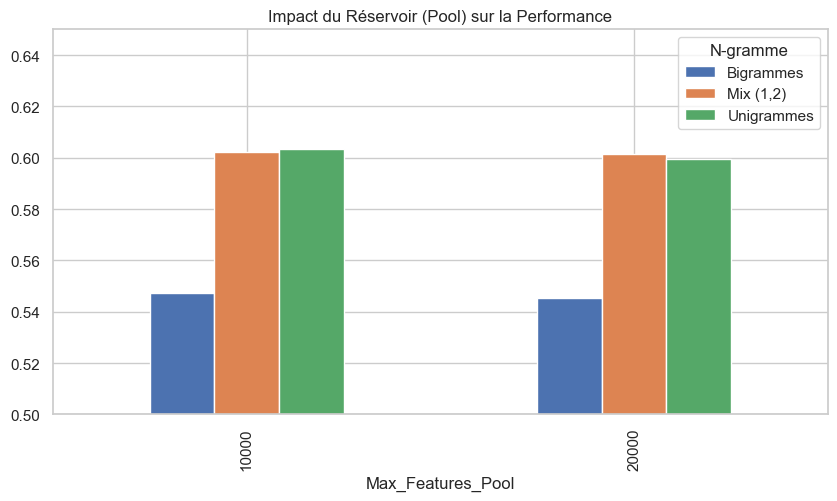

--- Meilleure Accuracy par catégorie pour Pool 10 000 ---


,Max_Features_Pool,N-gramme,K_Features,C_Param,Accuracy
5,10000,Unigrammes,2000,1.000000,0.603532
29,10000,"Mix (1,2)",2000,1.000000,0.602147
17,10000,Bigrammes,2000,1.000000,0.547438



--- Meilleure Accuracy par catégorie pour Pool 20 000 ---


,Max_Features_Pool,N-gramme,K_Features,C_Param,Accuracy
65,20000,"Mix (1,2)",2000,1.000000,0.601454
37,20000,Unigrammes,1500,1.000000,0.599377
54,20000,Bigrammes,2000,10.000000,0.545360


In [614]:
# 1. Graphique comparatif des pools
summary = df_comp.groupby(['Max_Features_Pool', 'N-gramme'])['Accuracy'].max().unstack()
summary.plot(kind='bar', figsize=(10, 5), ylim=(0.5, 0.65))
plt.title("Impact du Réservoir (Pool) sur la Performance")
plt.show()
# 2. Tableaux de synthèse par pool
print("--- Meilleure Accuracy par catégorie pour Pool 10 000 ---")
best_10k = df_comp[df_comp['Max_Features_Pool'] == 10000].sort_values('Accuracy', ascending=False).drop_duplicates('N-gramme')
display(best_10k.style.highlight_max(subset=['Accuracy'], color='lightgreen'))


print("\n--- Meilleure Accuracy par catégorie pour Pool 20 000 ---")
best_20k = df_comp[df_comp['Max_Features_Pool'] == 20000].sort_values('Accuracy', ascending=False).drop_duplicates('N-gramme')
display(best_20k.style.highlight_max(subset=['Accuracy'], color='lightgreen'))

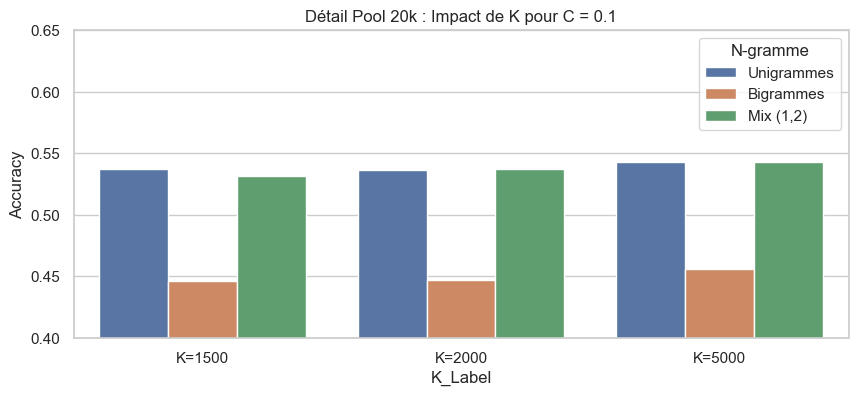

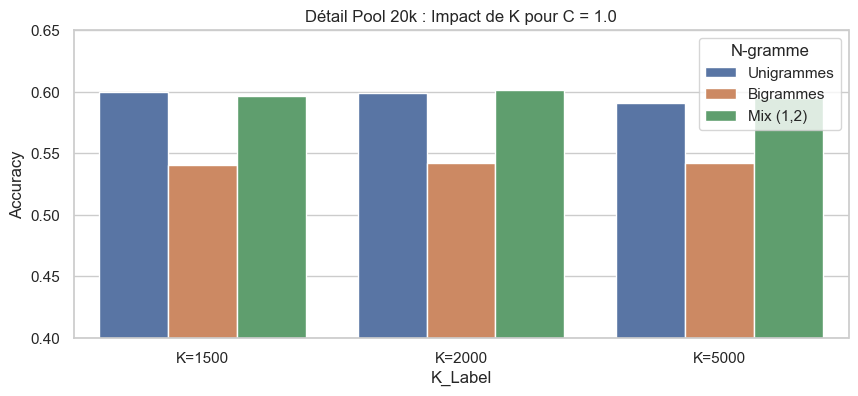

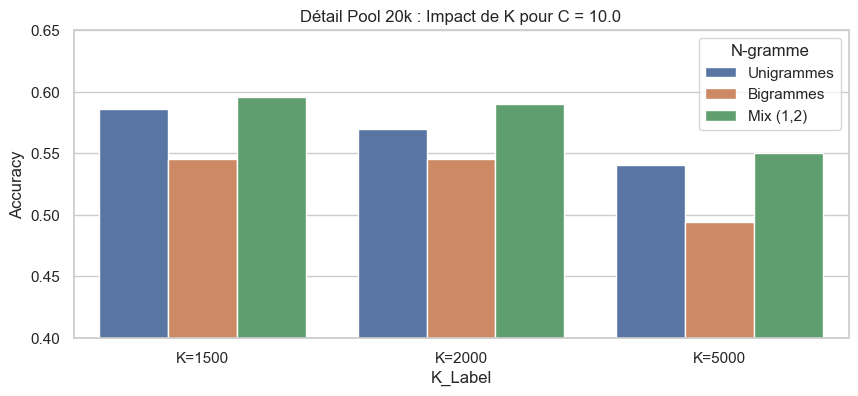

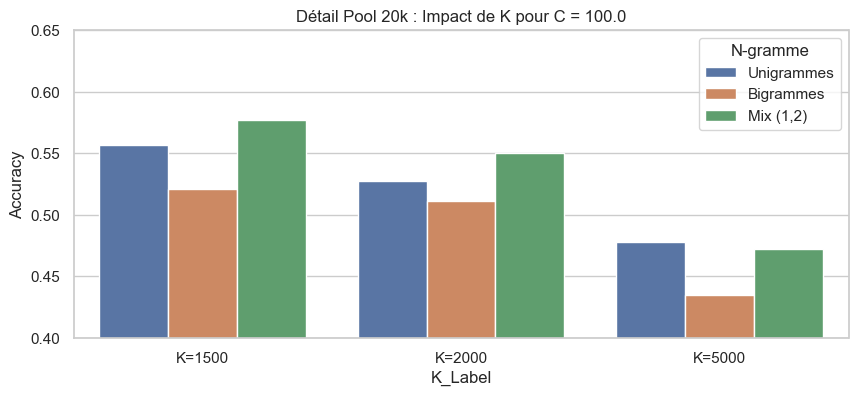

In [625]:
# Étude de sensibilité sur le pool gagnant (20k)
df_zoom = df_comp[df_comp['Max_Features_Pool'] == 20000].copy()
df_zoom['K_Label'] = df_zoom['K_Features'].apply(lambda x: f"K={x}")

for c_val in [0.1, 1.0,10.0, 100.0]:
    plt.figure(figsize=(10, 4))
    subset = df_zoom[df_zoom['C_Param'] == c_val]
    sns.barplot(x='K_Label', y='Accuracy', hue='N-gramme', data=subset)
    plt.title(f"Détail Pool 20k : Impact de K pour C = {c_val}")
    plt.ylim(0.40, 0.65)
    plt.show()

                      precision    recall  f1-score   support

           Neoplasms       0.75      0.74      0.74       633
    Digestive System       0.53      0.40      0.46       299
      Nervous System       0.58      0.39      0.47       385
      Cardiovascular       0.70      0.68      0.69       610
General Pathological       0.49      0.61      0.55       961

            accuracy                           0.60      2888
           macro avg       0.61      0.56      0.58      2888
        weighted avg       0.61      0.60      0.60      2888



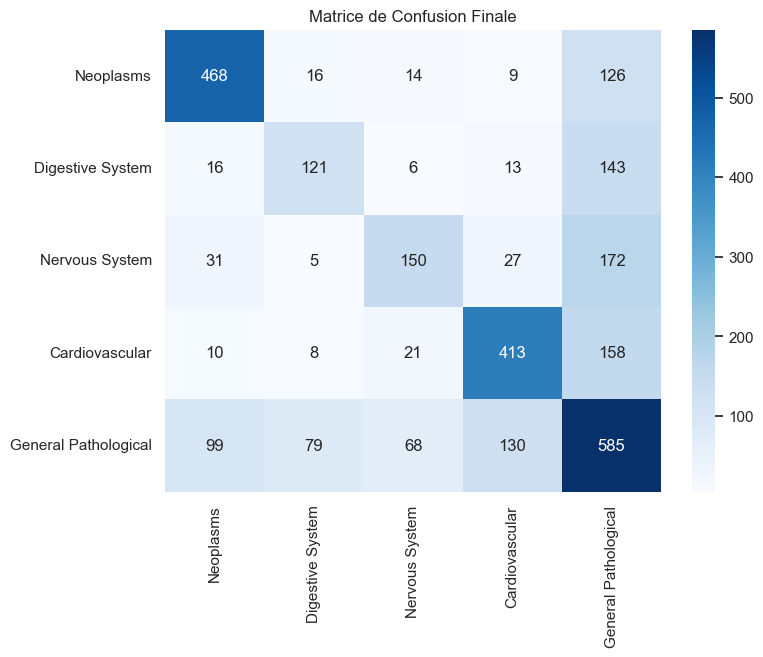

In [634]:
# Entraînement final avec les paramètres retenus
from sklearn.metrics import classification_report, confusion_matrix

# Paramètres : Mixte (1,2), Pool 20000, K 2000, C 1.0
vec_final = TfidfVectorizer(ngram_range=(1, 2), max_features=20000)
X_train_final = vec_final.fit_transform(X_train)
X_val_final = vec_final.transform(X_val)

selector_final = SelectKBest(chi2, k=2000)
X_train_final = selector_final.fit_transform(X_train_final, y_train)
X_val_final = selector_final.transform(X_val_final)

model_final = LogisticRegression(C=1.0, max_iter=2000)
model_final.fit(X_train_final, y_train)
y_pred = model_final.predict(X_val_final)

# Affichage des métriques
print(classification_report(y_val, y_pred, target_names=list(mapping.values())))

# Matrice de Confusion
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(mapping.values()), yticklabels=list(mapping.values()))
plt.title('Matrice de Confusion Finale')
plt.show()

In [656]:
# Prédiction sur le fichier 'test.dat'
def load_unlabeled_test(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f if line.strip()]

test_texts = load_unlabeled_test(r'C:\Users\L580\Downloads\archive\test.dat') 
df_test_final = pd.DataFrame({'text': test_texts})

# 1. Prétraitement (Nettoyage)
df_test_final['clean_text'] = df_test_final['text'].apply(preprocess_text)

# 2. Vectorisation et Sélection 
X_test_final = vec_final.transform(df_test_final['clean_text'])
X_test_final = selector_final.transform(X_test_final)

# 3. Prédiction
predictions = model_final.predict(X_test_final)
df_test_final['predicted_label'] = predictions
df_test_final['predicted_name'] = df_test_final['predicted_label'].map(mapping)

In [659]:
# --- AFFICHAGE DU RÉSUMÉ STATISTIQUE ---

print("="*60)
print("RÉPARTITION DES PRÉDICTIONS SUR LE FICHIER TEST.DAT")
print("="*60)
stats = df_test_final['predicted_name'].value_counts(normalize=True) * 100
for name, val in stats.items():
    print(f"[{name:<25}] : {val:>6.2f}% des abstracts")


# --- ÉCHANTILLON DE CLASSIFICATION (VÉRIFICATION SÉMANTIQUE) ---

print("\n" + "="*60)
print("ÉCHANTILLON DE CLASSIFICATION (TOP 20)")
print("="*60)

# Utilisation d'ANSI colors pour le gras et la couleur bleue
for i, row in df_test_final.head(20).iterrows():
    color_blue = "\033[1;34m" 
    reset = "\033[0m"
    print(f"\nID #{i} | {color_blue}PRÉDICTION : {row['predicted_name'].upper()}{reset}")
    # On affiche les 250 premiers caractères pour avoir assez de contexte
    print(f"TEXTE : {row['text'][:250]}...") 
    print("-" * 60)

RÉPARTITION DES PRÉDICTIONS SUR LE FICHIER TEST.DAT
[General Pathological     ] :  42.57% des abstracts
[Cardiovascular           ] :  20.90% des abstracts
[Neoplasms                ] :  20.63% des abstracts
[Nervous System           ] :   8.83% des abstracts
[Digestive System         ] :   7.06% des abstracts

ÉCHANTILLON DE CLASSIFICATION (TOP 20)

ID #0 | PRÉDICTION : GENERAL PATHOLOGICAL
TEXTE : Excision of limbal dermoids. We reviewed the clinical files of 10 patients who had undergone excision of unilateral epibulbar limbal dermoids. Preoperatively, all of the affected eyes had worse visual acuity (P less than .02) and more astigmatism (P ...
------------------------------------------------------------

ID #1 | PRÉDICTION : GENERAL PATHOLOGICAL
TEXTE : Bell's palsy. A diagnosis of exclusion. In cases of acute unilateral facial weakness, a careful and systematic evaluation is necessary to identify the cause. Idiopathic facial paralysis (Bell's palsy) is a diagnosis of exclusion. I